In [1]:
import xarray as xr
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import zoom
import glob

In [2]:
# nc_filelist = glob.glob(r"C:\Users\vwgei\Documents\PVOCAL\data\v0_1_5\ERA5_monthly_data\*.nc")

In [3]:
# # ==============
# # code to create monthly averaged dataset over 32 year period
# # ==============

# # Load all NetCDF files lazily
# nc_filelist = glob.glob(r"C:\Users\vwgei\Documents\PVOCAL\data\v0_1_5\ERA5_monthly_data\*.nc")
# ds = xr.open_mfdataset(nc_filelist, combine='by_coords', parallel=True)

# # Coarsen from 0.25° to 0.5° (average 2x2 grid cells)
# ds_coarse = ds.coarsen(latitude=2, longitude=2, boundary='trim').mean()

# # Group by month and calculate monthly averages across all years
# ds_monthly_avg = ds_coarse.groupby('valid_time.month').mean('valid_time')

# # Save to a new NetCDF file
# output_path = r"C:\Users\vwgei\Documents\PVOCAL\data\v0_1_5\ERA5_32yr_monthly_avg.nc"
# ds_monthly_avg.to_netcdf(output_path)

# print(f"✅ Monthly climatology saved to: {output_path}")

In [4]:
monthly_ave = xr.open_dataset(r"C:\Users\vwgei\Documents\PVOCAL\data\v0_1_5\ERA5_32yr_monthly_avg.nc")

In [5]:
monthly_ave

<xarray.Dataset> Size: 2GB
Dimensions:         (month: 12, pressure_level: 28, latitude: 360,
                     longitude: 720)
Coordinates:
    number          int64 8B ...
  * pressure_level  (pressure_level) float64 224B 1e+03 975.0 ... 100.0 70.0
  * latitude        (latitude) float64 3kB 89.88 89.38 88.88 ... -89.12 -89.62
  * longitude       (longitude) float64 6kB 0.125 0.625 1.125 ... 359.1 359.6
  * month           (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    z               (month, pressure_level, latitude, longitude) float32 348MB ...
    t               (month, pressure_level, latitude, longitude) float32 348MB ...
    q               (month, pressure_level, latitude, longitude) float32 348MB ...
    r               (month, pressure_level, latitude, longitude) float32 348MB ...
    o3              (month, pressure_level, latitude, longitude) float32 348MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts

In [6]:
time_averaged = monthly_ave.mean(dim='month')

In [7]:
time_averaged['z'] = time_averaged['z'] / 9.80665  # Convert geopotential to height

In [8]:
time_averaged

<xarray.Dataset> Size: 145MB
Dimensions:         (pressure_level: 28, latitude: 360, longitude: 720)
Coordinates:
    number          int64 8B ...
  * pressure_level  (pressure_level) float64 224B 1e+03 975.0 ... 100.0 70.0
  * latitude        (latitude) float64 3kB 89.88 89.38 88.88 ... -89.12 -89.62
  * longitude       (longitude) float64 6kB 0.125 0.625 1.125 ... 359.1 359.6
Data variables:
    z               (pressure_level, latitude, longitude) float32 29MB 103.9 ...
    t               (pressure_level, latitude, longitude) float32 29MB 259.3 ...
    q               (pressure_level, latitude, longitude) float32 29MB 0.0015...
    r               (pressure_level, latitude, longitude) float32 29MB 95.7 ....
    o3              (pressure_level, latitude, longitude) float32 29MB 5.688e...

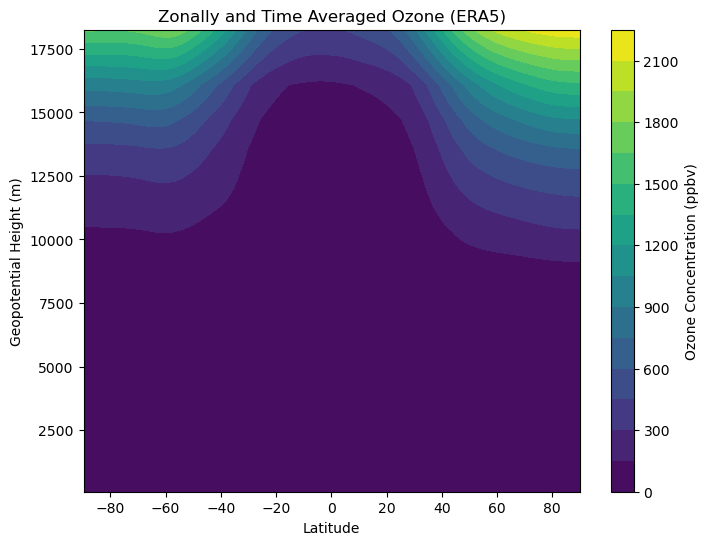

In [9]:
# Zonal average of 'o3' and 'z' over longitude
o3_zonal_avg = time_averaged['o3'].mean(dim='longitude')
z_zonal_avg = time_averaged['z'].mean(dim='longitude')

# Convert O3 from kg/kg to ppb
o3_zonal_avg_ppb = o3_zonal_avg * 6.04e8

# Get the mean geopotential height for each pressure level along latitude
z_mean = z_zonal_avg.mean(dim='latitude')

# Create a single plot
fig, ax = plt.subplots(figsize=(8, 6))

c = ax.contourf(o3_zonal_avg.latitude, z_mean, o3_zonal_avg_ppb,
                levels=20, cmap='viridis')



# Axis labels and title
ax.set_xlabel('Latitude')
ax.set_ylabel('Geopotential Height (m)')
ax.set_title('Zonally and Time Averaged Ozone (ERA5)')

# Add a colorbar
cbar = plt.colorbar(c, ax=ax)
# Update the colorbar label
cbar.set_label('Ozone Concentration (ppbv)')

# Show the plot
plt.savefig(r"C:\Users\vwgei\Documents\PVOCAL\plots\standalone\era5_o3_cross_section.png")
plt.show()

In [10]:
# OLD code to create a completely averaged climate

# # Open files lazily to avoid memory issues
# ds = xr.open_mfdataset(nc_filelist, combine='by_coords', parallel=True)

# # Check structure if needed
# print(ds)

# # Coarsen (downscale) from 0.25° to 0.5° (average 2x2 grid cells)
# ds_coarse = ds.coarsen(latitude=2, longitude=2, boundary='trim').mean()

# # Compute the mean over all 32 years
# ds_avg = ds_coarse.mean(dim='valid_time')

# # Save the averaged NetCDF to disk
# output_path = r"C:\Users\vwgei\Documents\PVOCAL\data\v0_1_5\ERA5_32yr_avg.nc"
# ds_avg.to_netcdf(output_path)

# print(f"✅ Averaged dataset saved to: {output_path}")

In [11]:
# OLD code to generate vertical lapse rates for all of our variables.

# # Load the monthly average dataset
# monthly_ave_path = r"C:\Users\vwgei\Documents\PVOCAL\data\v0_1_5\ERA5_32yr_monthly_avg.nc"
# ds = xr.open_dataset(monthly_ave_path)

# # Variables to calculate lapse rates for
# variables = ['t', 'q', 'r']

# # Convert geopotential to geopotential height
# g = 9.80665  # m/s^2
# z_data = ds['z'] / g  # Now in meters

# # Recalculate lapse rates with corrected height
# lapse_rates = {}
# for var in variables:
#     var_data = ds[var]  # Shape: (month, pressure_level, lat, lon)
    
#     # Calculate gradient of var and height along pressure_level axis
#     dvar_dp = np.gradient(var_data, axis=1)  # Change in variable
#     dz_dp = np.gradient(z_data, axis=1)      # Change in height (now in meters)

#     # Avoid division by zero
#     dz_dp[dz_dp == 0] = np.nan

#     # Corrected lapse rate: d(var)/d(height)
#     lapse_rate = dvar_dp / dz_dp

#     # Average lapse rates across pressure levels
#     lapse_rates[var] = np.nanmean(lapse_rate, axis=1)

# # Create a new xarray Dataset for the lapse rates
# lapse_ds = xr.Dataset(
#     {
#         't_lapse': (['month', 'latitude', 'longitude'], lapse_rates['t']),
#         'q_lapse': (['month', 'latitude', 'longitude'], lapse_rates['q']),
#         'r_lapse': (['month', 'latitude', 'longitude'], lapse_rates['r'])
#     },
#     coords={
#         'month': ds['month'],
#         'latitude': ds['latitude'],
#         'longitude': ds['longitude'],
#     }
# )

# # Save the lapse rate dataset to a new NetCDF file
# lapse_path = r"C:\Users\vwgei\Documents\PVOCAL\data\v0_1_5\ERA5_32yr_monthly_avg_lapse_rates.nc"
# lapse_ds.to_netcdf(lapse_path)

# print(f"✅ Lapse rates saved to: {lapse_path}")